<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/Computer_Vision/CV01/stickerimage1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
!pip install cmake
!pip install opencv-python
!conda install -y dlib

/bin/bash: line 1: conda: command not found


In [101]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


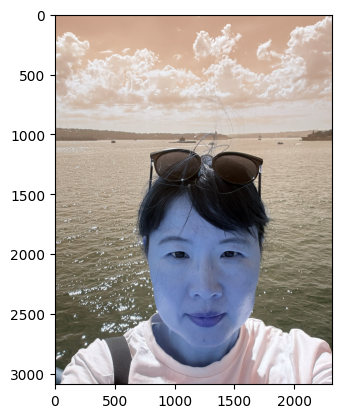

In [102]:

my_image_path = '/cotent/selfimage.jpeg'  # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

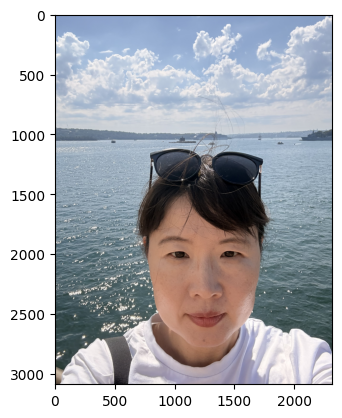

In [103]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [104]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [105]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


rectangles[[(723, 1789) (1682, 2747)]]


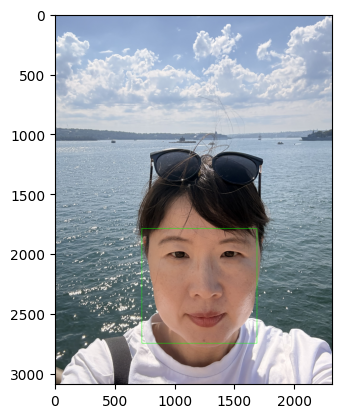

In [106]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b),(0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

### **Problem1>>   예시 사진과 다른 화질로 인한 것인지 얼굴 감지 박스의 선이 뚜렷하게 보이지 않는 문제가 있었고 얼굴의 정중앙에 자리 잡지 못한 것을 볼 수 있었다. 얼굴의 각도나 대칭성에 따라 감지의 정확도가 떨어진다고 여겨진다**

In [107]:
# 1. 모델 파일 다운로드
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

# 2. 목적지 폴더 생성 (폴더가 없으면 mv 명령어에서 에러가 납니다)
!mkdir -p /cotent/models

# 3. 파일을 목적지 폴더로 이동
!mv shape_predictor_68_face_landmarks.dat.bz2 /cotent/models

# 4. 해당 폴더로 이동하여 압축 해제 (bzip2는 압축을 풀면 원본 .bz2 파일을 삭제하고 .dat 파일을 생성합니다)
!cd /cotent && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 05:33:19--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 05:33:20--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  20.1MB/s    in 3.0s    

2026-04-20 05:33:23 (20.1 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [108]:
model_path = '/cotent/models/shape_predictor_68_face_landmarks.dat'
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [109]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


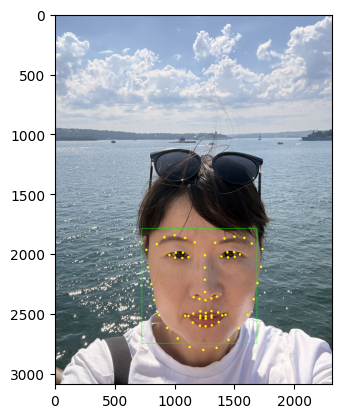

In [110]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 10, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [111]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(723, 1789) (1682, 2747)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1]
    w = h = dlib_rect.width()   # 얼굴 영역의 가로를 차지하는 픽셀의 수  → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(1249, 2320)
(x,y) : (1249,2320)
(w,h) : (960,960)


In [112]:
sticker_path ='/cotent/cat-whiskers.png'  # 수염 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 수염 이미지의 차원 확인

(960, 960, 3)


In [113]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 1249
# y는 이미지에서 코 부위의 y값 = 2320
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
refined_x = x - w // 2       # 1249- (187//2) = 1249-93 = 1156
refined_y = y - h//2         # 2320-187 = 2133
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다.

print (f'(x,y) : ({refined_x},{refined_y})')


(x,y) : (769,1840)


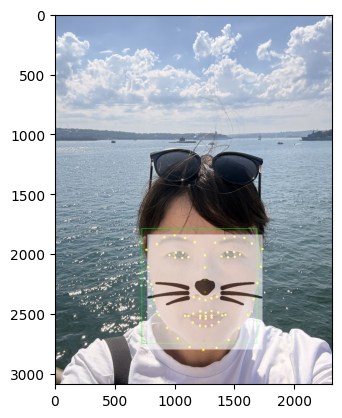

In [115]:
# 스티커가 배경 이미지 범위를 벗어나는지 체크 (예외 처리)
if refined_x < 0: refined_x = 0
if refined_y < 0: refined_y = 0

# 원본 이미지(img_show)에서 스티커가 들어갈 영역 추출
sticker_area = img_show[refined_y:refined_y+h, refined_x:refined_x+w]


# alpha: 원본 이미지 가중치 (0.0 ~ 1.0)
# beta: 스티커 이미지 가중치 (0.0 ~ 1.0) -> 이 값을 낮출수록 더 투명해집니다.
# gamma: 전체적으로 더해줄 밝기 (보통 0)
alpha = 0.7  # 원본 비중
beta = 0.3   # 스티커 비중 (0.3~0.5 추천)

# 두 이미지를 합성
img_show[refined_y:refined_y+h, refined_x:refined_x+w] = cv2.addWeighted(sticker_area, alpha, img_sticker, beta, 0)

# 결과 확인
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()



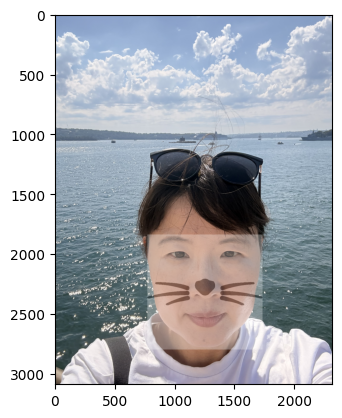

In [117]:
img_result = img_bgr.copy()

# 1. 스티커가 들어갈 영역 추출 (이미 계산된 refined_x, refined_y 사용)
sticker_area = img_result[refined_y:refined_y+h, refined_x:refined_x+w]

# 2. 투명도를 적용하여 합성 (원본 60%, 스티커 40% 비중)
img_result[refined_y:refined_y+h, refined_x:refined_x+w] = cv2.addWeighted(
    sticker_area, 0.7, img_sticker, 0.3, 0
)

# 3. 결과 출력 (박스와 점이 사라진 최종본)
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.show()